___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright Pierian Data</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Statsmodels Time Series Excercises
For this set of exercises we're using data from the Federal Reserve Economic Database (FRED) concerning the Industrial Production Index for Electricity and Gas Utilities from January 1970 to December 1989.

Data source: https://fred.stlouisfed.org/series/IPG2211A2N

<div class="alert alert-danger" style="margin: 10px"><strong>IMPORTANT NOTE!</strong> Make sure you don't run the cells directly above the example output shown, <br>otherwise you will end up writing over the example output!</div>

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import seaborn as sns
sns.set()

%config InlineBackend.figure_format ="svg"

In [8]:
file_path = r"C:\Users\ahmad\Desktop\Investing\Jose-Portilla-Python for Time Series Analysis\UDEMY_TSA_FINAL\UDEMY_TSA_FINAL\Data"
df = pd.read_csv(file_path + r"\EnergyProduction.csv" , index_col=[0], parse_dates=[0])
df.head()

,EnergyIndex
DATE,
1970-01-01,43.0869
1970-02-01,42.5577
1970-03-01,41.6215
1970-04-01,40.1982
1970-05-01,39.9321


### 1. Assign a frequency of 'MS' to the DatetimeIndex.

In [11]:
# CODE HERE
df.index.freq = "MS"
df.index


DatetimeIndex(['1970-01-01', '1970-02-01', '1970-03-01', '1970-04-01',
               '1970-05-01', '1970-06-01', '1970-07-01', '1970-08-01',
               '1970-09-01', '1970-10-01',
               ...
               '1989-03-01', '1989-04-01', '1989-05-01', '1989-06-01',
               '1989-07-01', '1989-08-01', '1989-09-01', '1989-10-01',
               '1989-11-01', '1989-12-01'],
              dtype='datetime64[ns]', name='DATE', length=240, freq='MS')

### 2. Plot the dataset.

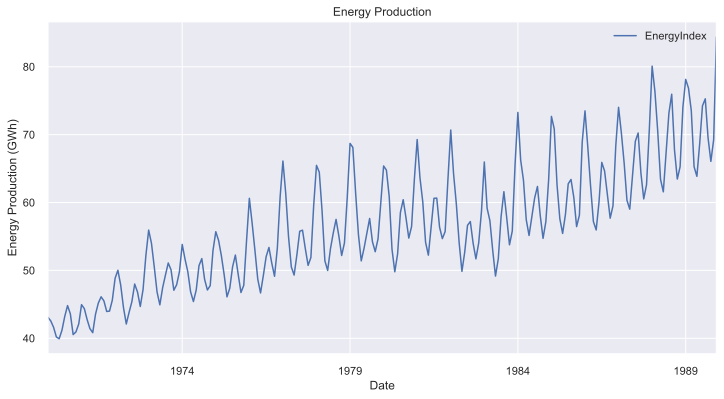

In [12]:
# CODE HERE
df.plot(figsize=(12, 6))
plt.title("Energy Production")
plt.ylabel("Energy Production (GWh)")
plt.xlabel("Date")
plt.show()

### 3. Add a column that shows a 12-month Simple Moving Average (SMA).<br>&nbsp;&nbsp;&nbsp;&nbsp;Plot the result.

In [15]:
span = 12
df["SMA_S"] = df["EnergyIndex"].rolling(window = span).mean()


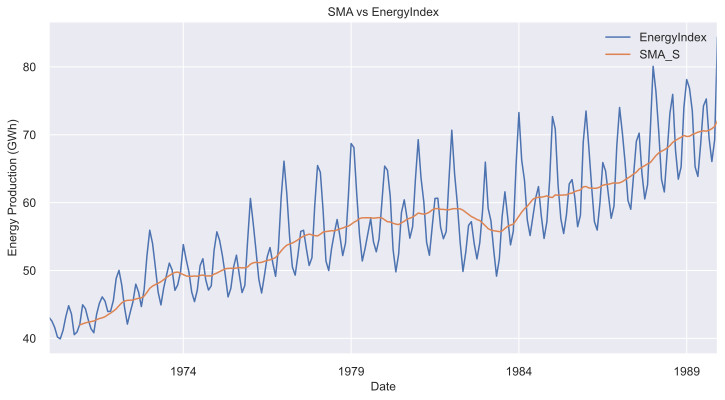

In [16]:
df.plot(figsize=(12, 6), title="SMA vs EnergyIndex", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Energy Production (GWh)", fontsize=12)
plt.legend(fontsize=12)
plt.show()

### 4. Add a column that shows an Exponentially Weighted Moving Average (EWMA) with a span of 12 using the statsmodels <tt>SimpleExpSmoothing</tt> function. Plot the result.

In [18]:
# DON'T FORGET TO PERFORM THE IMPORT!
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
alpha = 2/(1+span)
df["EWMA_S"] = SimpleExpSmoothing(endog = df["EnergyIndex"]).fit(smoothing_level=alpha, optimized=False).fittedvalues.shift(-1)

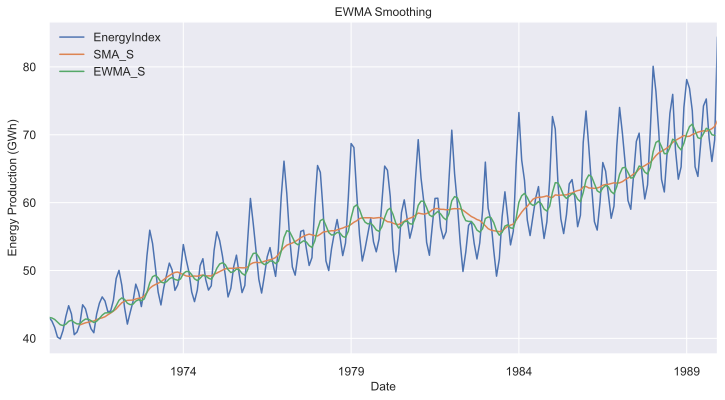

In [21]:
df.plot(figsize=(12, 6), title="EWMA Smoothing", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Energy Production (GWh)", fontsize=12)
plt.legend(fontsize=12)
plt.show()

### 5. Add a column to the DataFrame that shows a Holt-Winters fitted model using Triple Exponential Smoothing with multiplicative models. Plot the result.

In [22]:
# DON'T FORGET TO PERFORM THE IMPORT!
from statsmodels.tsa.holtwinters import ExponentialSmoothing
df["TES_S"] = ExponentialSmoothing(df["EnergyIndex"], trend ="mul" , seasonal = "mul", seasonal_periods=span).fit().fittedvalues.shift(-1)

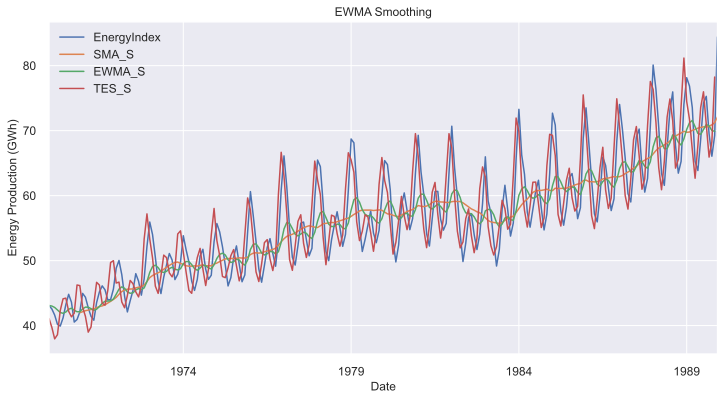

In [23]:
df.plot(figsize=(12, 6), title="EWMA Smoothing", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Energy Production (GWh)", fontsize=12)
plt.legend(fontsize=12)
plt.show()

### OPTIONAL: Plot the same  as above, but for only the first two years.

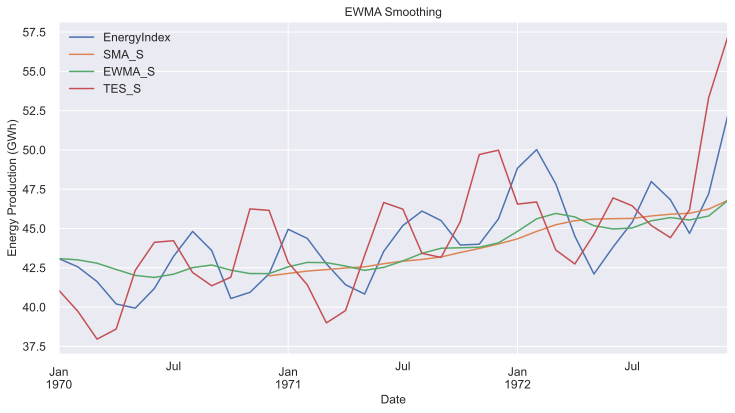

In [25]:
df.loc["1970":"1972"].plot(figsize=(12, 6), title="EWMA Smoothing", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Energy Production (GWh)", fontsize=12)
plt.legend(fontsize=12)
plt.show()

### BONUS QUESTION: There is a visible decline in the Industrial Production Index around 1982-1983.<br>Why do you think this might be?

There was a great depression in that period in the United States

## Great job!